In [1]:
# ============================================
# CELL 1: imports + device
# ============================================
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # avoid HF warning

import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    ElectraForQuestionAnswering,
)

import spacy
import re
from collections import defaultdict

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


In [2]:
# ============================================
# CELL 2: helper text utils (norm, sentence span, coarse NER type)
# ============================================
def norm_text(t: str) -> str:
    if t is None:
        return ""
    t = t.strip()
    t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

# very light coarse type: just look for obvious patterns
def coarse_type(text: str) -> str:
    text = text.strip()
    # $5 million -> MONEY
    if re.match(r"^\$?\d", text):
        return "MONEY"  # or CARDINAL; we will group numeric-like separately
    # year
    if re.match(r"^\d{4}$", text):
        return "DATE"
    # fallback
    return "O"

def span_in_same_sentence(ctx: str, gold_char_span, pred_char_span):
    """
    crude sentence detector: split on .?! and see where the gold/pred fall
    returns (same_sentence_bool, sent_start, sent_end)
    """
    g0, g1 = gold_char_span
    p0, p1 = pred_char_span
    # build sentence boundaries
    boundaries = []
    start = 0
    for m in re.finditer(r"[.?!]\s+", ctx):
        end = m.end()
        boundaries.append((start, end))
        start = end
    boundaries.append((start, len(ctx)))

    gold_sent = None
    for (s0, s1) in boundaries:
        if s0 <= g0 < s1:
            gold_sent = (s0, s1)
            break
    if gold_sent is None:
        return False, 0, len(ctx)

    s0, s1 = gold_sent
    same = (s0 <= p0 < s1)
    return same, s0, s1

# numeric-like check
def is_numeric_like_text(t: str) -> bool:
    t = t.strip()
    if re.fullmatch(r"\$?\d[\d,–-]*", t):
        return True
    if t.isdigit():
        return True
    return False


In [3]:
# ============================================
# CELL 3: load full SQuAD + tokenizer
# ============================================
raw = load_dataset("squad")
raw_train = raw["train"]          # ~87k
raw_val   = raw["validation"]     # ~10k

model_name = "google/electra-small-discriminator"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
print("train size:", len(raw_train), "val size:", len(raw_val))


train size: 87599 val size: 10570


In [4]:
# ============================================
# CELL 4: preprocessing / tokenization fns
# we add: offset_mapping, example_id, is_context_mask
# ============================================
max_length = 384
doc_stride = 128

def preprocess_train(examples):
    questions = [q.strip() for q in examples["question"]]
    contexts  = examples["context"]

    tokenized = tokenizer(
        questions,
        contexts,
        truncation="only_second",
        max_length=max_length,
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    sample_map = tokenized.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized["offset_mapping"]

    start_positions = []
    end_positions   = []
    example_ids     = []
    is_context_mask_all = []

    for i, offsets in enumerate(offset_mapping):
        input_id_example_idx = sample_map[i]
        answer = examples["answers"][input_id_example_idx]
        context = contexts[input_id_example_idx]
        example_ids.append(input_id_example_idx)

        # where does context start? token_type_ids == 1
        sequence_ids = tokenized.sequence_ids(i)

        # build is_context_mask
        is_ctx_mask = [1 if x == 1 else 0 for x in sequence_ids]
        is_context_mask_all.append(is_ctx_mask)

        if len(answer["answer_start"]) == 0:
            start_positions.append(0)
            end_positions.append(0)
            continue

        start_char = answer["answer_start"][0]
        end_char   = start_char + len(answer["text"][0])

        # find start token
        token_start_idx = 0
        while token_start_idx < len(sequence_ids) and sequence_ids[token_start_idx] != 1:
            token_start_idx += 1
        token_end_idx = len(sequence_ids) - 1
        while token_end_idx >= 0 and sequence_ids[token_end_idx] != 1:
            token_end_idx -= 1

        # if answer not fully inside
        if not (offsets[token_start_idx][0] <= start_char and
                offsets[token_end_idx][1] >= end_char):
            start_positions.append(0)
            end_positions.append(0)
        else:
            # move start idx
            s = token_start_idx
            while s < len(offsets) and offsets[s][0] <= start_char:
                s += 1
            start_positions.append(s-1)
            # move end idx
            e = token_end_idx
            while e >= 0 and offsets[e][1] >= end_char:
                e -= 1
            end_positions.append(e+1)

    tokenized["start_positions"] = start_positions
    tokenized["end_positions"]   = end_positions
    tokenized["example_id"]      = example_ids
    tokenized["is_context_mask"] = is_context_mask_all
    return tokenized


def preprocess_val(examples):
    # same but we don't need start/end
    questions = [q.strip() for q in examples["question"]]
    contexts  = examples["context"]

    tokenized = tokenizer(
        questions,
        contexts,
        truncation="only_second",
        max_length=max_length,
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )
    sample_map = tokenized.pop("overflow_to_sample_mapping")
    example_ids = []
    is_context_mask_all = []
    for i, seq_ids in enumerate(tokenized.sequence_ids()):
        ex_id = sample_map[i]
        example_ids.append(ex_id)
        is_ctx = [1 if x == 1 else 0 for x in seq_ids]
        is_context_mask_all.append(is_ctx)

    tokenized["example_id"]      = example_ids
    tokenized["is_context_mask"] = is_context_mask_all
    return tokenized


In [5]:
# =========================================
# SAFE TOKENIZATION FOR FULL SQuAD
# - handles sequence_ids == None
# - stores integer example_id using with_indices=True
# =========================================

max_len = 384

def preprocess_train(examples, indices):
    # examples: dict of lists from HF
    # indices: list of absolute dataset indices — we'll keep these as example_id
    questions = [q.lstrip() for q in examples["question"]]
    contexts  = examples["context"]

    tokenized = tokenizer(
        questions,
        contexts,
        truncation=True,
        max_length=max_len,
        padding="max_length",
        return_offsets_mapping=True,
        return_token_type_ids=True,
    )

    new_offset_mapping = []
    new_is_ctx_mask    = []
    new_example_ids    = []
    new_start_pos      = []
    new_end_pos        = []

    for i in range(len(contexts)):
        offsets = tokenized["offset_mapping"][i]
        seq_ids = tokenized.sequence_ids(i)

        # seq_ids can be None → make a dummy one
        if seq_ids is None:
            seq_ids = [0] * len(offsets)

        # find token span for the gold answer
        if len(examples["answers"][i]["text"]) == 0:
            # no answer → put CLS as start/end
            start_tok = 0
            end_tok   = 0
        else:
            ans_text  = examples["answers"][i]["text"][0]
            ans_start = examples["answers"][i]["answer_start"][0]
            ans_end   = ans_start + len(ans_text)

            # find token positions whose char span covers this
            start_tok = 0
            end_tok   = 0
            for j, (o0, o1) in enumerate(offsets):
                if o0 == ans_start:
                    start_tok = j
                if o1 == ans_end:
                    end_tok = j

        is_ctx = [1 if s == 1 else 0 for s in seq_ids]

        new_offset_mapping.append(offsets)
        new_is_ctx_mask.append(is_ctx)
        new_example_ids.append(int(indices[i]))  # <--- integer pointer to raw dataset
        new_start_pos.append(start_tok)
        new_end_pos.append(end_tok)

    tokenized["offset_mapping"]  = new_offset_mapping
    tokenized["is_context_mask"] = new_is_ctx_mask
    tokenized["example_id"]      = new_example_ids
    tokenized["start_positions"] = new_start_pos
    tokenized["end_positions"]   = new_end_pos

    return tokenized


def preprocess_val(examples, indices):
    questions = [q.lstrip() for q in examples["question"]]
    contexts  = examples["context"]

    tokenized = tokenizer(
        questions,
        contexts,
        truncation=True,
        max_length=max_len,
        padding="max_length",
        return_offsets_mapping=True,
        return_token_type_ids=True,
    )

    new_offset_mapping = []
    new_is_ctx_mask    = []
    new_example_ids    = []

    for i in range(len(contexts)):
        offsets = tokenized["offset_mapping"][i]
        seq_ids = tokenized.sequence_ids(i)

        if seq_ids is None:
            seq_ids = [0] * len(offsets)

        is_ctx = [1 if s == 1 else 0 for s in seq_ids]

        new_offset_mapping.append(offsets)
        new_is_ctx_mask.append(is_ctx)
        new_example_ids.append(int(indices[i]))   # again, integer index into raw_val

    tokenized["offset_mapping"]  = new_offset_mapping
    tokenized["is_context_mask"] = new_is_ctx_mask
    tokenized["example_id"]      = new_example_ids

    return tokenized


# -------------------------------------------------------
# actually map
# (replace raw_train/raw_val with your names if different)
# -------------------------------------------------------
use_train = raw_train         # full 87,599
use_val   = raw_val           # full 10,570

tokenized_train = use_train.map(
    preprocess_train,
    batched=True,
    with_indices=True,
    remove_columns=use_train.column_names,
)

tokenized_val = use_val.map(
    preprocess_val,
    batched=True,
    with_indices=True,
    remove_columns=use_val.column_names,
)

print(tokenized_train)
print(tokenized_val)



Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'is_context_mask', 'example_id', 'start_positions', 'end_positions'],
    num_rows: 87599
})
Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'is_context_mask', 'example_id'],
    num_rows: 10570
})


In [6]:
# ============================================
# CELL 6: baseline collate + dataloaders
# ============================================
def qa_collate_fn(batch):
    out = {}
    for k in batch[0].keys():
        vals = [b[k] for b in batch]
        if k in ["offset_mapping", "is_context_mask"]:
            out[k] = vals
        else:
            out[k] = torch.tensor(vals, dtype=torch.long)
    return out

train_dl = DataLoader(
    tokenized_train,
    batch_size=16,
    shuffle=True,
    collate_fn=qa_collate_fn,
)

val_dl = DataLoader(
    tokenized_val,
    batch_size=16,
    shuffle=False,
    collate_fn=qa_collate_fn,
)
print("dataloaders ready")


dataloaders ready


In [7]:
# ============================================
# CELL 7: baseline training
# ============================================
def train_baseline(model, dataloader, epochs=1, lr=3e-5, device=device, max_steps=None):
    model.train()
    optim = torch.optim.AdamW(model.parameters(), lr=lr)
    step = 0
    for ep in range(epochs):
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attn      = batch["attention_mask"].to(device)
            start_pos = batch["start_positions"].to(device)
            end_pos   = batch["end_positions"].to(device)

            optim.zero_grad()
            out = model(
                input_ids=input_ids,
                attention_mask=attn,
                start_positions=start_pos,
                end_positions=end_pos,
            )
            loss = out.loss
            loss.backward()
            optim.step()

            if step % 80 == 0:
                print(f"[BASELINE] step {step} | loss={loss.item():.4f}")
            step += 1
            if max_steps and step >= max_steps:
                return


def evaluate_simple(model, val_tok, val_raw, device=device, max_eval=None):
    model.eval()
    correct = 0
    total   = 0
    with torch.no_grad():
        for i, feat in enumerate(val_tok):
            if max_eval and i >= max_eval:
                break
            ex_id = int(feat["example_id"])
            raw_ex = val_raw[ex_id]
            ctx = raw_ex["context"]

            if len(raw_ex["answers"]["text"]) == 0:
                continue
            gold = raw_ex["answers"]["text"][0]
            gold_norm = norm_text(gold)

            inp = torch.tensor(feat["input_ids"]).unsqueeze(0).to(device)
            att = torch.tensor(feat["attention_mask"]).unsqueeze(0).to(device)
            out = model(input_ids=inp, attention_mask=att)
            s = int(out.start_logits.argmax(-1).item())
            e = int(out.end_logits.argmax(-1).item())

            offsets = feat["offset_mapping"]
            is_ctx  = feat["is_context_mask"]
            if s < len(offsets) and e < len(offsets) and is_ctx[s] == 1 and is_ctx[e] == 1:
                c0 = offsets[s][0]; c1 = offsets[e][1]
                pred = ctx[c0:c1]
            else:
                pred = ""
            if norm_text(pred) == gold_norm:
                correct += 1
            total += 1
    em = 100.0 * correct / total
    return {"EM": em}


# ---- actually train baseline ----
baseline_model = ElectraForQuestionAnswering.from_pretrained(model_name).to(device)
train_baseline(baseline_model, train_dl, epochs=1, lr=3e-5, device=device, max_steps=1200)
baseline_scores = evaluate_simple(baseline_model, tokenized_val, use_val, device=device)
print("BASELINE dev:", baseline_scores)


Some weights of ElectraForQuestionAnswering were not initialized from the model checkpoint at google/electra-small-discriminator and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[BASELINE] step 0 | loss=6.1248
[BASELINE] step 80 | loss=4.1919
[BASELINE] step 160 | loss=3.5158
[BASELINE] step 240 | loss=2.8352
[BASELINE] step 320 | loss=2.9595
[BASELINE] step 400 | loss=2.3332
[BASELINE] step 480 | loss=1.9056
[BASELINE] step 560 | loss=1.1331
[BASELINE] step 640 | loss=1.6770
[BASELINE] step 720 | loss=1.4685
[BASELINE] step 800 | loss=2.8990
[BASELINE] step 880 | loss=1.4251
[BASELINE] step 960 | loss=2.0752
[BASELINE] step 1040 | loss=1.4180
[BASELINE] step 1120 | loss=2.0336
BASELINE dev: {'EM': 45.562913907284766}


In [8]:
# ============================================
# CELL 8: build sentence+NER index on TRAIN (for contrastive mining)
# ============================================
# load spaCy
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    # if not installed in your env, download
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm")

def build_sentence_ner_index(raw_split):
    """
    returns a LIST where idx i corresponds to raw_split[i]
    each item:
      {
        "sents": [(s0,s1), ...],
        "ners":  [("PERSON", c0, c1), ...]
      }
    """
    out = []
    for ex in raw_split:
        doc = nlp(ex["context"])
        sents = [(s.start_char, s.end_char) for s in doc.sents]
        ners  = [(ent.label_, ent.start_char, ent.end_char) for ent in doc.ents]
        out.append({
            "sents": sents,
            "ners": ners,
        })
    return out

train_sentence_ner_index = build_sentence_ner_index(use_train)
print("built NER index for", len(train_sentence_ner_index), "train examples")


built NER index for 87599 train examples


In [9]:
# ============================================
# CELL 9: contrastive dataset + collate
# (tokenized_example, raw_example)
# ============================================
class ContrastiveDataset(Dataset):
    def __init__(self, tok_ds, raw_ds):
        self.tok_ds = tok_ds
        self.raw_ds = raw_ds

    def __len__(self):
        return len(self.tok_ds)

    def __getitem__(self, idx):
        tok_item = self.tok_ds[idx]
        raw_item = self.raw_ds[int(tok_item["example_id"])]
        raw_item = {
            "id_idx": int(tok_item["example_id"]),
            "context": raw_item["context"],
            "question": raw_item["question"],
            "answers": raw_item["answers"],
        }
        return tok_item, raw_item

def contrastive_collate_fn(batch):
    tok_batch = [b[0] for b in batch]
    raw_batch = [b[1] for b in batch]
    out = {}
    for k in tok_batch[0].keys():
        vals = [x[k] for x in tok_batch]
        if k in ["offset_mapping", "is_context_mask"]:
            out[k] = vals
        else:
            out[k] = torch.tensor(vals, dtype=torch.long)
    return out, raw_batch


In [10]:
# ============================================
# CELL 10: pick HARD subset for contrastive
# (you can make this smarter; for now: long contexts)
# ============================================
def looks_ambiguous(ex):
    # crude: long contexts more likely to have multiple entities
    return len(ex["context"]) > 220

hard_raw = use_train.filter(looks_ambiguous)
# now we need corresponding tokenized rows:
hard_indices = [i for i, ex in enumerate(use_train) if looks_ambiguous(ex)]
hard_tok     = tokenized_train.select(hard_indices)

contrastive_ds = ContrastiveDataset(hard_tok, use_train)
contrastive_dl = DataLoader(
    contrastive_ds,
    batch_size=16,
    shuffle=True,
    collate_fn=contrastive_collate_fn,
)
print("contrastive dataset:", len(contrastive_ds))


contrastive dataset: 86289


In [11]:
# ============================================
# CELL 11: contrastive helpers (mine hard negs)
# ============================================
def find_ner_hard_negs(raw_ex, tok_ex, sent_ner_entry, max_negs=4):
    """
    Try to find NER spans in the SAME sentence as gold, with SAME label.
    Returns list of dicts with { "neg_tok": (s,e) } in token space.
    """
    gold_start_char = raw_ex["answers"]["answer_start"][0]
    gold_text       = raw_ex["answers"]["text"][0]
    gold_type       = coarse_type(gold_text)

    sents = sent_ner_entry["sents"]
    ners  = sent_ner_entry["ners"]

    gold_sent_idx = None
    for si, (s0, s1) in enumerate(sents):
        if s0 <= gold_start_char < s1:
            gold_sent_idx = si
            break
    if gold_sent_idx is None:
        return []

    sent_s0, sent_s1 = sents[gold_sent_idx]
    # collect ner spans in that sentence
    cand = []
    for (label, c0, c1) in ners:
        if not (sent_s0 <= c0 < sent_s1):
            continue
        # we want same semantic type-ish
        if gold_type != "O" and label not in ["PERSON","ORG","GPE","LOC","DATE","TIME","MONEY","CARDINAL","ORDINAL"]:
            continue
        cand.append((label, c0, c1))

    # map char spans to token spans using tok_ex["offset_mapping"]
    offsets = tok_ex["offset_mapping"]
    is_ctx  = tok_ex["is_context_mask"]

    def char_to_tok(c0, c1):
        s_tok = None
        e_tok = None
        for ti, (o0, o1) in enumerate(offsets):
            if is_ctx[ti] == 0:
                continue
            if o0 <= c0 < o1 and s_tok is None:
                s_tok = ti
            if o0 < c1 <= o1:
                e_tok = ti
        if s_tok is None or e_tok is None:
            return None
        return (s_tok, e_tok)

    gold_tok = (tok_ex["start_positions"], tok_ex["end_positions"])
    negs = []
    for (_, c0, c1) in cand:
        maybe = char_to_tok(c0, c1)
        if maybe is None:
            continue
        if maybe == gold_tok:
            continue
        negs.append({"neg_tok": maybe})
        if len(negs) >= max_negs:
            break
    return gold_tok, negs


def contrastive_train_step(
    model,
    batch_tok,
    batch_raw,
    sentence_ner_index,
    alpha=0.1,
    margin=0.25,
    device=device,
):
    model.train()
    input_ids = batch_tok["input_ids"].to(device)
    attention_mask = batch_tok["attention_mask"].to(device)
    start_positions = batch_tok["start_positions"].to(device)
    end_positions   = batch_tok["end_positions"].to(device)
    offsets_list    = batch_tok["offset_mapping"]
    is_ctx_list     = batch_tok["is_context_mask"]

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        start_positions=start_positions,
        end_positions=end_positions,
    )
    loss_qa     = outputs.loss
    start_logits = outputs.start_logits
    end_logits   = outputs.end_logits

    cl_losses = []
    pair_count = 0

    B = input_ids.size(0)
    for i in range(B):
        raw_ex = batch_raw[i]
        ex_id  = raw_ex["id_idx"]
        sent_ner_entry = sentence_ner_index[ex_id]
        tok_ex = {
            "offset_mapping": offsets_list[i],
            "is_context_mask": is_ctx_list[i],
            "start_positions": int(start_positions[i].item()),
            "end_positions": int(end_positions[i].item()),
        }

        gold_tok, ner_negs = find_ner_hard_negs(raw_ex, tok_ex, sent_ner_entry, max_negs=4)
        if len(ner_negs) == 0:
            continue

        gs, ge = gold_tok
        gold_score = start_logits[i, gs] + end_logits[i, ge]

        for neg in ner_negs:
            ns, ne = neg["neg_tok"]
            neg_score = start_logits[i, ns] + end_logits[i, ne]
            cl = torch.relu(margin - (gold_score - neg_score))
            cl_losses.append(cl)
            pair_count += 1

    if cl_losses:
        loss_cl = torch.stack(cl_losses).mean()
        loss = loss_qa + alpha * loss_cl
    else:
        loss_cl = torch.tensor(0.0, device=device)
        loss = loss_qa

    loss.backward()
    return loss.item(), loss_qa.item(), loss_cl.item(), pair_count


In [12]:
# ============================================
# CELL 12: contrastive train loop
# ============================================
def train_contrastive(
    model,
    dataloader,
    sentence_ner_index,
    epochs=1,
    lr=5e-5,
    alpha=0.1,
    margin=0.25,
    device=device,
):
    optim = torch.optim.AdamW(model.parameters(), lr=lr)
    step = 0
    for ep in range(epochs):
        for batch_tok, batch_raw in dataloader:
            optim.zero_grad()
            loss, qa, cl, n_pairs = contrastive_train_step(
                model,
                batch_tok,
                batch_raw,
                sentence_ner_index,
                alpha=alpha,
                margin=margin,
                device=device,
            )
            optim.step()
            if step % 80 == 0:
                print(f"[CONTRASTIVE] step {step} | loss={loss:.4f} | qa={qa:.4f} | cl={cl:.4f} | pairs={n_pairs}")
            step += 1
    print("contrastive training done.")


In [13]:
 # ============================================
# CELL 13: per-example printer (your version)
# ============================================
ALL_NER_TYPES = {
    "PERSON","ORG","GPE","LOC","DATE","TIME","CARDINAL","ORDINAL","MONEY","PERCENT",
    "EVENT","LAW","NORP","PRODUCT","WORK_OF_ART","LANGUAGE"
}

def stats_after_training(
    baseline_model,
    contrast_model,
    val_with_offsets,
    val_raw,
    device=device,
    print_examples=True,
    print_only_errors=False,
    max_print=30,
):
    baseline_model.eval()
    contrast_model.eval()

    total_scanned = 0
    base_correct_global = 0
    cont_correct_global = 0

    hard_cnt = base_hard = cont_hard = 0
    numeric_cnt = base_numeric = cont_numeric = 0
    over_cnt = base_over = cont_over = 0

    printed = 0

    for i, feat in enumerate(val_with_offsets):
        ex_id = int(feat["example_id"])
        raw_ex = val_raw[ex_id]
        ctx = raw_ex["context"]
        q   = raw_ex["question"]

        if len(raw_ex["answers"]["text"]) == 0:
            continue
        gold_text = raw_ex["answers"]["text"][0]
        gold_start_char = raw_ex["answers"]["answer_start"][0]
        gold_end_char   = gold_start_char + len(gold_text)

        offsets = feat["offset_mapping"]
        is_ctx  = feat["is_context_mask"]

        inp = torch.tensor(feat["input_ids"]).unsqueeze(0).to(device)
        att = torch.tensor(feat["attention_mask"]).unsqueeze(0).to(device)
        with torch.no_grad():
            out_b = baseline_model(input_ids=inp, attention_mask=att)
            out_c = contrast_model(input_ids=inp, attention_mask=att)

        b_s = int(out_b.start_logits.argmax(-1).item())
        b_e = int(out_b.end_logits.argmax(-1).item())
        c_s = int(out_c.start_logits.argmax(-1).item())
        c_e = int(out_c.end_logits.argmax(-1).item())

        def get_span(s_tok, e_tok):
            if s_tok < 0 or e_tok < 0 or s_tok >= len(offsets) or e_tok >= len(offsets):
                return ""
            if is_ctx[s_tok] == 0 or is_ctx[e_tok] == 0:
                return ""
            c0 = offsets[s_tok][0]; c1 = offsets[e_tok][1]
            return ctx[c0:c1]

        base_text = get_span(b_s, b_e)
        cont_text = get_span(c_s, c_e)

        total_scanned += 1

        gold_norm = norm_text(gold_text)
        base_hit  = (norm_text(base_text) == gold_norm)
        cont_hit  = (norm_text(cont_text) == gold_norm)

        if base_hit:  base_correct_global += 1
        if cont_hit:  cont_correct_global += 1

        # hard check
        is_hard = False
        if base_text.strip():
            same_sent, s0, s1 = span_in_same_sentence(
                ctx,
                (gold_start_char, gold_end_char),
                (offsets[b_s][0], offsets[b_e][1])
            )
            if same_sent and coarse_type(base_text) == coarse_type(gold_text):
                is_hard = True
        if is_hard:
            hard_cnt += 1
            if base_hit:  base_hard += 1
            if cont_hit:  cont_hard += 1

        # numeric
        is_num = is_numeric_like_text(gold_text)
        if is_num:
            numeric_cnt += 1
            if base_hit:  base_numeric += 1
            if cont_hit:  cont_numeric += 1

        # overlong
        is_over = base_text and len(base_text) - len(gold_text) >= 15
        if is_over:
            over_cnt += 1
            if base_hit:  base_over += 1
            if cont_hit:  cont_over += 1

        if print_examples and printed < max_print:
            to_print = True
            if print_only_errors:
                to_print = (not base_hit) or (not cont_hit)
            if to_print:
                print("="*100)
                print(f"Example {i}")
                print("Q:", q)
                print("SENTENCE:", ctx[s0:s1] if is_hard else ctx)
                print("GOLD: ", gold_text)
                print("BASE:", base_text, "✅" if base_hit else "❌")
                print("CONT:", cont_text, "✅" if cont_hit else "❌")
                printed += 1

    print("=========== SUMMARY STATS (ALL SLICES) ===========")
    print(f"Scanned: {total_scanned}")
    gb = 100.0 * base_correct_global / total_scanned
    gc = 100.0 * cont_correct_global / total_scanned
    print(f"GLOBAL: baseline {gb:.1f}% | contrastive {gc:.1f}% | Δ {gc-gb:+.1f}")

    if hard_cnt > 0:
        bb = 100.0 * base_hard / hard_cnt
        cc = 100.0 * cont_hard / hard_cnt
        print(f"HARD ({hard_cnt}): baseline {bb:.1f}% | contrastive {cc:.1f}% | Δ {cc-bb:+.1f}")

    if numeric_cnt > 0:
        bb = 100.0 * base_numeric / numeric_cnt
        cc = 100.0 * cont_numeric / numeric_cnt
        print(f"NUMERIC ({numeric_cnt}): baseline {bb:.1f}% | contrastive {cc:.1f}% | Δ {cc-bb:+.1f}")

    if over_cnt > 0:
        bb = 100.0 * base_over / over_cnt
        cc = 100.0 * cont_over / over_cnt
        print(f"OVERLONG ({over_cnt}): baseline {bb:.1f}% | contrastive {cc:.1f}% | Δ {cc-bb:+.1f}")


In [14]:
# ============================================
# CELL A: baseline training + eval helpers
# ============================================
import torch
from torch.utils.data import DataLoader

def evaluate_model(model, val_tok, val_raw, device="cuda"):
    """
    super simple EM over your tokenized val set + raw val set
    assumes:
      - val_tok[i]["example_id"] points into val_raw
      - model is ElectraForQuestionAnswering
    """
    model.eval()
    total = 0
    correct = 0

    for i in range(len(val_tok)):
        feat = val_tok[i]
        ex_id = int(feat["example_id"])
        raw_ex = val_raw[ex_id]

        if len(raw_ex["answers"]["text"]) == 0:
            continue

        gold_text = raw_ex["answers"]["text"][0]
        ctx = raw_ex["context"]

        offsets = feat["offset_mapping"]
        is_ctx = feat["is_context_mask"]

        input_ids = torch.tensor(feat["input_ids"]).unsqueeze(0).to(device)
        att_mask  = torch.tensor(feat["attention_mask"]).unsqueeze(0).to(device)

        with torch.no_grad():
            out = model(input_ids=input_ids, attention_mask=att_mask)
        s = int(out.start_logits.argmax(-1).item())
        e = int(out.end_logits.argmax(-1).item())

        if s < 0 or e < 0 or s >= len(offsets) or e >= len(offsets):
            pred_text = ""
        elif is_ctx[s] == 0 or is_ctx[e] == 0:
            pred_text = ""
        else:
            c0 = offsets[s][0]
            c1 = offsets[e][1]
            pred_text = ctx[c0:c1]

        # tiny normalizer so "5 million" vs "$5 million" isn't too harsh
        def _norm(t):
            return t.strip().lower()

        if _norm(pred_text) == _norm(gold_text):
            correct += 1
        total += 1

    em = 100.0 * correct / max(1, total)
    return {"EM": em}


def train_baseline(
    model,
    train_loader,
    epochs=1,
    lr=3e-5,
    device="cuda",
    max_steps=None,
):
    model.train()
    optim = torch.optim.AdamW(model.parameters(), lr=lr)
    step = 0

    for ep in range(epochs):
        for batch in train_loader:
            # your train_loader was built from tokenized_train
            # so batch should be a dict of tensors/lists
            input_ids = batch["input_ids"].to(device)
            att_mask  = batch["attention_mask"].to(device)
            start_pos = batch["start_positions"].to(device)
            end_pos   = batch["end_positions"].to(device)

            optim.zero_grad()

            out = model(
                input_ids=input_ids,
                attention_mask=att_mask,
                start_positions=start_pos,
                end_positions=end_pos,
            )
            loss = out.loss
            loss.backward()
            optim.step()

            if step % 80 == 0:
                print(f"[BASELINE] step {step} | loss={loss.item():.4f}")

            step += 1
            if max_steps is not None and step >= max_steps:
                print("baseline training done (max_steps).")
                return

    print("baseline training done.")


In [15]:
# ============================================
# CELL B: copy baseline -> contrastive, train, print
# ============================================

# 0) we assume you already have:
#    model_name, device, train_dl, contrastive_dl,
#    tokenized_val, use_val, train_sentence_ner_index,
#    stats_after_training, train_contrastive
#    defined in earlier cells.

# 1) make sure baseline_model exists
if "baseline_model" not in globals():
    print("baseline_model not found in this session — recreating + quick train...")
    baseline_model = ElectraForQuestionAnswering.from_pretrained(model_name).to(device)
    train_baseline(
        baseline_model,
        train_dl,
        epochs=1,
        lr=3e-5,
        device=device,
        max_steps=400,   # or 800 if you want a bit better
    )
    base_scores = evaluate_model(baseline_model, tokenized_val, use_val, device=device)
    print("BASELINE dev:", base_scores)
else:
    print("baseline_model already in memory.")

# 2) copy baseline -> contrastive model
contrast_model = ElectraForQuestionAnswering.from_pretrained(model_name).to(device)
contrast_model.load_state_dict(baseline_model.state_dict())

# 3) train contrastive
train_contrastive(
    contrast_model,
    contrastive_dl,
    train_sentence_ner_index,
    epochs=1,
    lr=5e-5,
    alpha=0.1,
    margin=0.25,
    device=device,
)

# 4) print detailed per-example stuff
stats_after_training(
    baseline_model,
    contrast_model,
    tokenized_val,   # tokenized 500
    use_val,         # raw 500
    device=device,
    print_examples=True,
    print_only_errors=False,
    max_print=25,
)


baseline_model already in memory.


Some weights of ElectraForQuestionAnswering were not initialized from the model checkpoint at google/electra-small-discriminator and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[CONTRASTIVE] step 0 | loss=1.3632 | qa=1.3216 | cl=0.4156 | pairs=42
[CONTRASTIVE] step 80 | loss=1.5012 | qa=1.4787 | cl=0.2255 | pairs=43
[CONTRASTIVE] step 160 | loss=1.2243 | qa=1.2139 | cl=0.1040 | pairs=38
[CONTRASTIVE] step 240 | loss=1.8692 | qa=1.8585 | cl=0.1073 | pairs=39
[CONTRASTIVE] step 320 | loss=1.0124 | qa=1.0086 | cl=0.0377 | pairs=28
[CONTRASTIVE] step 400 | loss=1.7304 | qa=1.7078 | cl=0.2261 | pairs=34
[CONTRASTIVE] step 480 | loss=1.6579 | qa=1.6365 | cl=0.2142 | pairs=40
[CONTRASTIVE] step 560 | loss=1.5050 | qa=1.4901 | cl=0.1488 | pairs=45
[CONTRASTIVE] step 640 | loss=1.8996 | qa=1.8760 | cl=0.2363 | pairs=46
[CONTRASTIVE] step 720 | loss=1.1619 | qa=1.1602 | cl=0.0170 | pairs=37
[CONTRASTIVE] step 800 | loss=1.7515 | qa=1.7244 | cl=0.2709 | pairs=37
[CONTRASTIVE] step 880 | loss=0.9876 | qa=0.9789 | cl=0.0874 | pairs=36
[CONTRASTIVE] step 960 | loss=0.9647 | qa=0.9601 | cl=0.0464 | pairs=40
[CONTRASTIVE] step 1040 | loss=1.9773 | qa=1.9739 | cl=0.0345 | pai

In [16]:
# ============================
# PRINT STATS + EXAMPLES
# ============================
import torch
import re
from collections import defaultdict

# ---- tiny helpers (safe fallbacks) ----
def norm_text(t):
    if t is None:
        return ""
    return re.sub(r"\s+", " ", t.strip().lower())

def coarse_type(text):
    # super simple heuristic – if you already have spaCy-based one, delete this and use yours
    t = text.strip()
    if re.fullmatch(r"\$?\d[\d,–-]*", t):
        return "CARDINAL"
    if any(m in t.lower() for m in ["january","february","march","april","may","june",
                                    "july","august","september","october","november","december",
                                    "201", "202", "199"]):
        return "DATE"
    return "O"

def span_in_same_sentence(ctx, gold_span, pred_span):
    """
    very cheap sentence splitter: split on '.', '?', '!'
    returns (same_sent, sent_start, sent_end)
    """
    g0, g1 = gold_span
    p0, p1 = pred_span
    # find sentence boundaries
    boundaries = [0]
    for i, ch in enumerate(ctx):
        if ch in ".?!":
            boundaries.append(i+1)
    boundaries.append(len(ctx))
    gold_sent = None
    pred_sent = None
    for s in range(len(boundaries)-1):
        s0, s1 = boundaries[s], boundaries[s+1]
        if s0 <= g0 < s1:
            gold_sent = (s0, s1)
        if s0 <= p0 < s1:
            pred_sent = (s0, s1)
    if gold_sent and pred_sent and gold_sent == pred_sent:
        return True, gold_sent[0], gold_sent[1]
    # if we couldn't find sentences properly, just return whole ctx
    return False, 0, len(ctx)

ALL_NER_TYPES = {
    "PERSON","ORG","GPE","LOC","DATE","TIME","CARDINAL","ORDINAL","MONEY","PERCENT",
    "EVENT","LAW","NORP","PRODUCT","WORK_OF_ART","LANGUAGE"
}

def is_numeric_like_text(t: str) -> bool:
    t = t.strip()
    if re.fullmatch(r"\$?\d[\d,–-]*", t):
        return True
    if t.isdigit():
        return True
    return False


def stats_after_training(
    baseline_model,
    contrast_model,
    val_tok,
    val_raw,
    device="cuda",
    max_scan=500,          # you can make 520 or len(val_tok)
    print_examples=True,
    print_only_errors=False,
    max_print=25,
):
    baseline_model.eval()
    contrast_model.eval()

    total_scanned = 0
    base_correct_global = 0
    cont_correct_global = 0

    hard_same_sent_same_type = 0
    base_correct_on_hard = 0
    cont_correct_on_hard = 0

    numeric_like = 0
    base_correct_numeric = 0
    cont_correct_numeric = 0

    overlong_cases = 0
    base_correct_overlong = 0
    cont_correct_overlong = 0

    per_type_total = defaultdict(int)
    per_type_base  = defaultdict(int)
    per_type_cont  = defaultdict(int)

    no_entity_total = 0
    no_entity_base  = 0
    no_entity_cont  = 0

    printed = 0

    for i in range(min(max_scan, len(val_tok))):
        feat = val_tok[i]
        ex_id = int(feat["example_id"])
        raw_ex = val_raw[ex_id]
        ctx = raw_ex["context"]
        question = raw_ex["question"]

        if len(raw_ex["answers"]["text"]) == 0:
            continue
        gold_text = raw_ex["answers"]["text"][0]
        gold_start_char = raw_ex["answers"]["answer_start"][0]
        gold_end_char   = gold_start_char + len(gold_text)

        offsets = feat["offset_mapping"]
        is_ctx = feat["is_context_mask"]

        inp = torch.tensor(feat["input_ids"]).unsqueeze(0).to(device)
        att = torch.tensor(feat["attention_mask"]).unsqueeze(0).to(device)

        with torch.no_grad():
            out_b = baseline_model(input_ids=inp, attention_mask=att)
            out_c = contrast_model(input_ids=inp, attention_mask=att)

        b_s = int(out_b.start_logits.argmax(-1).item())
        b_e = int(out_b.end_logits.argmax(-1).item())
        c_s = int(out_c.start_logits.argmax(-1).item())
        c_e = int(out_c.end_logits.argmax(-1).item())

        def get_span(s_tok, e_tok):
            if s_tok < 0 or e_tok < 0: return ""
            if s_tok >= len(offsets) or e_tok >= len(offsets): return ""
            if is_ctx[s_tok] == 0 or is_ctx[e_tok] == 0: return ""
            c0 = offsets[s_tok][0]
            c1 = offsets[e_tok][1]
            return ctx[c0:c1]

        base_text = get_span(b_s, b_e)
        cont_text = get_span(c_s, c_e)

        total_scanned += 1

        gold_norm = norm_text(gold_text)
        base_norm = norm_text(base_text)
        cont_norm = norm_text(cont_text)

        base_hit = (base_norm == gold_norm)
        cont_hit = (cont_norm == gold_norm)

        if base_hit: base_correct_global += 1
        if cont_hit: cont_correct_global += 1

        gold_coarse = coarse_type(gold_text)
        if gold_coarse in ALL_NER_TYPES:
            per_type_total[gold_coarse] += 1
            if base_hit: per_type_base[gold_coarse] += 1
            if cont_hit: per_type_cont[gold_coarse] += 1
        else:
            no_entity_total += 1
            if base_hit: no_entity_base += 1
            if cont_hit: no_entity_cont += 1

        # HARD case check
        is_hard = False
        if base_text.strip():
            base_char_span = (offsets[b_s][0], offsets[b_e][1])
            same_sent, sent_s, sent_e = span_in_same_sentence(
                ctx, (gold_start_char, gold_end_char), base_char_span
            )
            if same_sent:
                base_type = coarse_type(base_text)
                if base_type == gold_coarse:
                    is_hard = True
                    hard_same_sent_same_type += 1
                    if base_hit: base_correct_on_hard += 1
                    if cont_hit: cont_correct_on_hard += 1
        else:
            sent_s, sent_e = 0, len(ctx)

        # numeric
        is_num = is_numeric_like_text(gold_text)
        if is_num:
            numeric_like += 1
            if base_hit: base_correct_numeric += 1
            if cont_hit: cont_correct_numeric += 1

        # overlong
        is_overlong = False
        if base_text and len(base_text) - len(gold_text) >= 15:
            is_overlong = True
            overlong_cases += 1
            if base_hit: base_correct_overlong += 1
            if cont_hit: cont_correct_overlong += 1

        # ---- print examples ----
        if print_examples and printed < max_print:
            ok = True
            if print_only_errors:
                ok = (not base_hit) or (not cont_hit)
            if ok:
                print("="*100)
                print(f"Example {i} (id={ex_id})")
                print(f"QUESTION: {question}")
                print(f"SENTENCE: {ctx[sent_s:sent_e]}")
                print(f"GOLD:      {gold_text}")
                print(f"BASELINE:  {base_text}   {'✅' if base_hit else '❌'}")
                print(f"OURS:      {cont_text}   {'✅' if cont_hit else '❌'}")
                tags = []
                if is_hard: tags.append("HARD")
                if is_num: tags.append("NUMERIC")
                if is_overlong: tags.append("OVERLONG")
                if tags:
                    print("TAGS:", ", ".join(tags))
                printed += 1

    # ---- summary ----
    print("=========== SUMMARY STATS (ALL SLICES) ===========")
    print(f"Scanned examples: {total_scanned}\n")
    g_base = 100.0 * base_correct_global / total_scanned
    g_cont = 100.0 * cont_correct_global / total_scanned
    print("0) GLOBAL")
    print(f"   baseline EM:    {base_correct_global}/{total_scanned} ({g_base:.1f}%)")
    print(f"   contrastive EM: {cont_correct_global}/{total_scanned} ({g_cont:.1f}%)")
    print(f"   Δ: {g_cont - g_base:+.1f} pts\n")

    print("1) HARD: same sentence + same type")
    print(f"   #hard cases found: {hard_same_sent_same_type}")
    if hard_same_sent_same_type > 0:
        b_acc = 100.0 * base_correct_on_hard / hard_same_sent_same_type
        c_acc = 100.0 * cont_correct_on_hard / hard_same_sent_same_type
        print(f"   baseline:   {base_correct_on_hard}/{hard_same_sent_same_type} ({b_acc:.1f}%)")
        print(f"   contrastive:{cont_correct_on_hard}/{hard_same_sent_same_type} ({c_acc:.1f}%)")
        print(f"   Δ: {c_acc - b_acc:+.1f} pts\n")

    print("2) NUMERIC / MONEY-LIKE / SCORE-LIKE")
    print(f"   #numeric-like: {numeric_like}")
    if numeric_like > 0:
        b_acc = 100.0 * base_correct_numeric / numeric_like
        c_acc = 100.0 * cont_correct_numeric / numeric_like
        print(f"   baseline:    {base_correct_numeric}/{numeric_like} ({b_acc:.1f}%)")
        print(f"   contrastive: {cont_correct_numeric}/{numeric_like} ({c_acc:.1f}%)")
        print(f"   Δ: {c_acc - b_acc:+.1f} pts\n")

    print("3) OVER-LONG ANSWERS (baseline grabbed >=15 chars too many)")
    print(f"   #overlong: {overlong_cases}")
    if overlong_cases > 0:
        b_acc = 100.0 * base_correct_overlong / overlong_cases
        c_acc = 100.0 * cont_correct_overlong / overlong_cases
        print(f"   baseline:    {base_correct_overlong}/{overlong_cases} ({b_acc:.1f}%)")
        print(f"   contrastive: {cont_correct_overlong}/{overlong_cases} ({c_acc:.1f}%)")
        print(f"   Δ: {c_acc - b_acc:+.1f} pts\n")

    print("4) PER NER TYPE")
    for t in sorted(per_type_total.keys()):
        tot = per_type_total[t]
        b = per_type_base[t]
        c = per_type_cont[t]
        b_acc = 100.0 * b / tot if tot else 0.0
        c_acc = 100.0 * c / tot if tot else 0.0
        print(f"   {t:10s}: base {b}/{tot} ({b_acc:5.1f}%) | ours {c}/{tot} ({c_acc:5.1f}%) | Δ {c_acc - b_acc:+.1f}")
    print("")
    print("5) NO-ENTITY (O)")
    print(f"   total: {no_entity_total}")
    if no_entity_total > 0:
        b_acc = 100.0 * no_entity_base / no_entity_total
        c_acc = 100.0 * no_entity_cont / no_entity_total
        print(f"   baseline:    {no_entity_base}/{no_entity_total} ({b_acc:.1f}%)")
        print(f"   contrastive: {no_entity_cont}/{no_entity_total} ({c_acc:.1f}%)")
        print(f"   Δ: {c_acc - b_acc:+.1f} pts")
    print("===============================================")


# ============================
# call it
# ============================
# if you were using the full val set:
#   val_tok = tokenized_val
#   val_raw = raw_val
stats_after_training(
    baseline_model,
    contrast_model,
    tokenized_val,
    raw_val,
    device=device,
    print_examples=True,
    print_only_errors=False,   # set True if you only want mistakes
    max_print=30,              # change to see more
    max_scan=500,              # change to 10570 if you want full SQuAD v1.1 val
)


Example 0 (id=0)
QUESTION: Which NFL team represented the AFC at Super Bowl 50?
SENTENCE:  The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title.
GOLD:      Denver Broncos
BASELINE:  Denver Broncos   ✅
OURS:      Denver Broncos   ✅
TAGS: HARD
Example 1 (id=1)
QUESTION: Which NFL team represented the NFC at Super Bowl 50?
SENTENCE: Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title. The game was played on February 7, 2016, at Levi's Stadium in the San Francisco Bay Area at Santa Clara, California. As this was the 50th Super Bowl, the league emphasized the "golden anniversary" with various gold-themed initiat

In [17]:
import torch
import re

def _norm_text(t):
    return re.sub(r"\s+", " ", t.strip().lower()) if t else ""

def _extract_span(feat, ctx, s_tok, e_tok):
    offsets = feat["offset_mapping"]
    is_ctx  = feat["is_context_mask"]
    if s_tok < 0 or e_tok < 0:
        return ""
    if s_tok >= len(offsets) or e_tok >= len(offsets):
        return ""
    if is_ctx[s_tok] == 0 or is_ctx[e_tok] == 0:
        return ""
    c0 = offsets[s_tok][0]
    c1 = offsets[e_tok][1]
    return ctx[c0:c1]

def collect_examples_for_table(
    baseline_model,
    contrast_model,
    tokenized_val,
    raw_val,
    device="cuda",
    max_scan=1000,
    max_keep=10,
    only_where_contrastive_fixes=True,
):
    baseline_model.eval()
    contrast_model.eval()

    collected = []

    for i in range(min(max_scan, len(tokenized_val))):
        feat = tokenized_val[i]
        ex_id = int(feat["example_id"])
        raw_ex = raw_val[ex_id]

        # skip if no gold
        if len(raw_ex["answers"]["text"]) == 0:
            continue

        ctx = raw_ex["context"]
        q   = raw_ex["question"]
        gold = raw_ex["answers"]["text"][0]
        gold_norm = _norm_text(gold)

        inp = torch.tensor(feat["input_ids"]).unsqueeze(0).to(device)
        att = torch.tensor(feat["attention_mask"]).unsqueeze(0).to(device)

        with torch.no_grad():
            out_b = baseline_model(input_ids=inp, attention_mask=att)
            out_c = contrast_model(input_ids=inp, attention_mask=att)

        b_s = int(out_b.start_logits.argmax(-1).item())
        b_e = int(out_b.end_logits.argmax(-1).item())
        c_s = int(out_c.start_logits.argmax(-1).item())
        c_e = int(out_c.end_logits.argmax(-1).item())

        base_ans = _extract_span(feat, ctx, b_s, b_e)
        cont_ans = _extract_span(feat, ctx, c_s, c_e)

        base_hit = (_norm_text(base_ans) == gold_norm)
        cont_hit = (_norm_text(cont_ans) == gold_norm)

        # if we only want the "look, we fixed it" examples:
        if only_where_contrastive_fixes and not (not base_hit and cont_hit):
            continue

        # try to get the sentence that contains the gold answer
        # (cheap splitter, same as your earlier function)
        sent_start, sent_end = 0, len(ctx)
        # gold char span
        g0 = raw_ex["answers"]["answer_start"][0]
        g1 = g0 + len(gold)
        bounds = [0]
        for pos, ch in enumerate(ctx):
            if ch in ".?!":
                bounds.append(pos+1)
        bounds.append(len(ctx))
        for s in range(len(bounds)-1):
            s0, s1 = bounds[s], bounds[s+1]
            if s0 <= g0 < s1:
                sent_start, sent_end = s0, s1
                break

        collected.append({
            "passage": ctx[sent_start:sent_end].strip(),
            "question": q,
            "gold": gold,
            "baseline": base_ans,
            "contrastive": cont_ans,
            "baseline_hit": base_hit,
            "contrastive_hit": cont_hit,
            "example_id": ex_id,
        })

        if len(collected) >= max_keep:
            break

    return collected


# ============================
# actually run it
# ============================
examples = collect_examples_for_table(
    baseline_model,
    contrast_model,
    tokenized_val,
    raw_val,
    device=device,
    max_scan=2000,      # scan more to find good ones
    max_keep=8,         # how many to print
    only_where_contrastive_fixes=True,
)

# pretty-print them
for idx, ex in enumerate(examples, 1):
    print("="*110)
    print(f"Example {idx} (id={ex['example_id']})")
    print(f"PASSAGE:     {ex['passage']}")
    print(f"QUESTION:    {ex['question']}")
    print(f"GOLD:        {ex['gold']}")
    print(f"BASELINE:    {ex['baseline']}   {'✅' if ex['baseline_hit'] else '❌'}")
    print(f"+CONTRASTIVE:{ex['contrastive']}   {'✅' if ex['contrastive_hit'] else '❌'}")


Example 1 (id=3)
PASSAGE:     The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title.
QUESTION:    Which NFL team won Super Bowl 50?
GOLD:        Denver Broncos
BASELINE:       ❌
+CONTRASTIVE:Denver Broncos   ✅
Example 2 (id=9)
PASSAGE:     The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title.
QUESTION:    What does AFC stand for?
GOLD:        American Football Conference
BASELINE:    American Football Conference (AFC) champion Denver Broncos   ❌
+CONTRASTIVE:American Football Conference   ✅
Example 3 (id=13)
PASSAGE:     The game was played on February 7, 2016, at Levi's Stadium in the San Francisco Bay Area at Santa Clara, California.
QUESTION:    What city did Super Bowl 50 take place in?
GOLD:        Santa Clara
BASELINE:    Santa C

In [18]:
import torch
import matplotlib.pyplot as plt

def norm_text(s):
    return " ".join(s.strip().lower().split())

def get_span_text_from_feat(feat, ctx, start_tok, end_tok):
    offsets = feat["offset_mapping"]
    is_ctx = feat["is_context_mask"]
    if start_tok < 0 or end_tok < 0 or start_tok >= len(offsets) or end_tok >= len(offsets):
        return ""
    if is_ctx[start_tok] == 0 or is_ctx[end_tok] == 0:
        return ""
    c0 = offsets[start_tok][0]
    c1 = offsets[end_tok][1]
    return ctx[c0:c1]

def eval_em(model, val_tok, val_raw, device="cuda"):
    model.eval()
    correct = 0
    total = 0
    for i in range(len(val_tok)):
        feat = val_tok[i]
        raw_ex = val_raw[int(feat["example_id"])]
        if len(raw_ex["answers"]["text"]) == 0:
            continue
        gold_text = raw_ex["answers"]["text"][0]
        ctx = raw_ex["context"]

        inp = torch.tensor(feat["input_ids"]).unsqueeze(0).to(device)
        att = torch.tensor(feat["attention_mask"]).unsqueeze(0).to(device)

        with torch.no_grad():
            out = model(input_ids=inp, attention_mask=att)

        s = int(out.start_logits.argmax(-1).item())
        e = int(out.end_logits.argmax(-1).item())
        pred_text = get_span_text_from_feat(feat, ctx, s, e)

        if norm_text(pred_text) == norm_text(gold_text):
            correct += 1
        total += 1

    em = 100.0 * correct / max(total, 1)
    return em, correct, total

# ====== RUN IT ======
baseline_em, b_corr, b_tot = eval_em(baseline_model, val_with_offsets, raw_val, device=device)
contrast_em, c_corr, c_tot = eval_em(contrast_model, val_with_offsets, raw_val, device=device)

print("=== EM RESULTS (dev) ===")
print(f"Baseline EM:    {baseline_em:.2f}%  ({b_corr}/{b_tot})")
print(f"Contrastive EM: {contrast_em:.2f}%  ({c_corr}/{c_tot})")
print(f"Δ (contrast - base): {contrast_em - baseline_em:+.2f} pts")

# ====== PLOT ======
labels = ["Baseline", "Contrastive"]
vals = [baseline_em, contrast_em]

plt.figure(figsize=(4,4))
plt.bar(labels, vals)
plt.ylim(0, 100)
plt.ylabel("Exact Match (EM) %")
plt.title("Dev EM comparison")
for i, v in enumerate(vals):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.show()


NameError: name 'val_with_offsets' is not defined

In [19]:
import torch

def norm_text(s):
    return " ".join(s.strip().lower().split())

def _pred_span(feat, ctx, start_tok, end_tok):
    offsets = feat["offset_mapping"]
    is_ctx  = feat["is_context_mask"]
    if start_tok < 0 or end_tok < 0 or start_tok >= len(offsets) or end_tok >= len(offsets):
        return ""
    if is_ctx[start_tok] == 0 or is_ctx[end_tok] == 0:
        return ""
    c0 = offsets[start_tok][0]
    c1 = offsets[end_tok][1]
    return ctx[c0:c1]

def eval_em_plain(model, val_tok, val_raw, device="cuda"):
    model.eval()
    correct = 0
    total = 0
    for i in range(len(val_tok)):
        feat = val_tok[i]
        raw_ex = val_raw[int(feat["example_id"])]
        if len(raw_ex["answers"]["text"]) == 0:
            continue
        gold = raw_ex["answers"]["text"][0]
        ctx  = raw_ex["context"]

        inp = torch.tensor(feat["input_ids"]).unsqueeze(0).to(device)
        att = torch.tensor(feat["attention_mask"]).unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(input_ids=inp, attention_mask=att)

        s = int(out.start_logits.argmax(-1).item())
        e = int(out.end_logits.argmax(-1).item())
        pred = _pred_span(feat, ctx, s, e)

        if norm_text(pred) == norm_text(gold):
            correct += 1
        total += 1

    em = 100.0 * correct / max(total, 1)
    return em, correct, total

def print_em_report(baseline_model, contrast_model, val_tok, raw_val, device="cuda"):
    base_em, b_corr, b_tot = eval_em_plain(baseline_model,  val_tok, raw_val, device)
    cont_em, c_corr, c_tot = eval_em_plain(contrast_model, val_tok, raw_val, device)

    print("========== DEV EM REPORT ==========")
    print(f"Baseline EM:     {base_em:6.2f}%  ({b_corr}/{b_tot})")
    print(f"Contrastive EM:  {cont_em:6.2f}%  ({c_corr}/{c_tot})")
    print(f"Δ (contr - base): {cont_em - base_em:+.2f} pts\n")

    max_len = 40
    base_bar = "#" * int((base_em/100.0) * max_len)
    cont_bar = "#" * int((cont_em/100.0) * max_len)
    print("ASCII EM chart")
    print(f"Base       | {base_bar}")
    print(f"Contrast   | {cont_bar}")
    print("====================================")

    with open("em_results.txt", "w") as f:
        f.write("model,em,correct,total\n")
        f.write(f"baseline,{base_em:.2f},{b_corr},{b_tot}\n")
        f.write(f"contrastive,{cont_em:.2f},{c_corr},{c_tot}\n")
    print("Saved to em_results.txt")


In [20]:
# if yours are named like this:
val_with_offsets = tokenized_val     # tokenized dev
raw_val_split    = raw_val           # raw dev

print_em_report(
    baseline_model,
    contrast_model,
    val_with_offsets,
    raw_val_split,
    device=device,
)


========== DEV EM REPORT ==========
Baseline EM:      45.56%  (4816/10570)
Contrastive EM:   53.56%  (5661/10570)
Δ (contr - base): +7.99 pts

ASCII EM chart
Base       | ##################
Contrast   | #####################
Saved to em_results.txt


In [21]:
import torch
import re

# --------- helpers ----------
def norm_text(s):
    # same as before
    return " ".join(s.strip().lower().split())

def _pred_span(feat, ctx, start_tok, end_tok):
    offsets = feat["offset_mapping"]
    is_ctx  = feat["is_context_mask"]
    if start_tok < 0 or end_tok < 0 or start_tok >= len(offsets) or end_tok >= len(offsets):
        return ""
    if is_ctx[start_tok] == 0 or is_ctx[end_tok] == 0:
        return ""
    c0 = offsets[start_tok][0]
    c1 = offsets[end_tok][1]
    return ctx[c0:c1]

def _simple_tokenize(s):
    # very simple tokenizer for F1
    s = s.lower().strip()
    # remove extra punctuation spacing
    s = re.sub(r"\s+", " ", s)
    return s.split()

def squad_f1(pred, gold):
    """standard token-level F1"""
    pred_toks = _simple_tokenize(pred)
    gold_toks = _simple_tokenize(gold)
    if len(pred_toks) == 0 and len(gold_toks) == 0:
        return 1.0
    if len(pred_toks) == 0 or len(gold_toks) == 0:
        return 0.0
    common = {}
    for t in pred_toks:
        common[t] = common.get(t, 0) + 1
    overlap = 0
    for t in gold_toks:
        if common.get(t, 0) > 0:
            overlap += 1
            common[t] -= 1
    if overlap == 0:
        return 0.0
    precision = overlap / len(pred_toks)
    recall    = overlap / len(gold_toks)
    return 2 * precision * recall / (precision + recall)

# --------- evaluator ----------
def eval_em_f1_plain(model, val_tok, val_raw, device="cuda"):
    model.eval()
    em_correct = 0
    total = 0
    f1_sum = 0.0

    for i in range(len(val_tok)):
        feat   = val_tok[i]
        raw_ex = val_raw[int(feat["example_id"])]
        if len(raw_ex["answers"]["text"]) == 0:
            continue
        gold = raw_ex["answers"]["text"][0]
        ctx  = raw_ex["context"]

        inp = torch.tensor(feat["input_ids"]).unsqueeze(0).to(device)
        att = torch.tensor(feat["attention_mask"]).unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(input_ids=inp, attention_mask=att)

        s = int(out.start_logits.argmax(-1).item())
        e = int(out.end_logits.argmax(-1).item())
        pred = _pred_span(feat, ctx, s, e)

        # EM
        if norm_text(pred) == norm_text(gold):
            em_correct += 1

        # F1
        f1 = squad_f1(pred, gold)
        f1_sum += f1

        total += 1

    em  = 100.0 * em_correct / max(total, 1)
    f1p = 100.0 * f1_sum / max(total, 1)
    return {"EM": em, "F1": f1p, "em_correct": em_correct, "total": total}

def print_em_f1_report(
    baseline_model,
    contrast_model,
    val_tok,
    raw_val,
    device="cuda",
    save_path="metrics_results.txt",
):
    base = eval_em_f1_plain(baseline_model,  val_tok, raw_val, device)
    cont = eval_em_f1_plain(contrast_model, val_tok, raw_val, device)

    print("========== DEV METRICS REPORT ==========")
    print(f"Baseline EM:     {base['EM']:6.2f}%  ({base['em_correct']}/{base['total']})")
    print(f"Contrastive EM:  {cont['EM']:6.2f}%  ({cont['em_correct']}/{cont['total']})")
    print(f"Δ EM (contr - base): {cont['EM'] - base['EM']:+.2f} pts\n")

    print(f"Baseline F1:     {base['F1']:6.2f}%")
    print(f"Contrastive F1:  {cont['F1']:6.2f}%")
    print(f"Δ F1 (contr - base): {cont['F1'] - base['F1']:+.2f} pts\n")

    # ASCII bars
    max_len = 40
    base_em_bar  = "#" * int((base["EM"]/100.0)  * max_len)
    cont_em_bar  = "#" * int((cont["EM"]/100.0)  * max_len)
    base_f1_bar  = "#" * int((base["F1"]/100.0)  * max_len)
    cont_f1_bar  = "#" * int((cont["F1"]/100.0)  * max_len)

    print("ASCII EM chart")
    print(f"Base EM      | {base_em_bar}")
    print(f"Contrast EM  | {cont_em_bar}\n")

    print("ASCII F1 chart")
    print(f"Base F1      | {base_f1_bar}")
    print(f"Contrast F1  | {cont_f1_bar}")
    print("=========================================")

    # save
    with open(save_path, "w") as f:
        f.write("model,EM,F1,correct,total\n")
        f.write(f"baseline,{base['EM']:.2f},{base['F1']:.2f},{base['em_correct']},{base['total']}\n")
        f.write(f"contrastive,{cont['EM']:.2f},{cont['F1']:.2f},{cont['em_correct']},{cont['total']}\n")
    print(f"Saved to {save_path}")


In [22]:
# if your tokenized dev is called tokenized_val
val_with_offsets = tokenized_val

# raw dev: could be raw_val OR val_small
raw_dev = raw_val   # or val_small

print_em_f1_report(
    baseline_model,
    contrast_model,
    val_with_offsets,
    raw_dev,
    device=device,
)


========== DEV METRICS REPORT ==========
Baseline EM:      45.56%  (4816/10570)
Contrastive EM:   53.56%  (5661/10570)
Δ EM (contr - base): +7.99 pts

Baseline F1:      62.63%
Contrastive F1:   70.95%
Δ F1 (contr - base): +8.32 pts

ASCII EM chart
Base EM      | ##################
Contrast EM  | #####################

ASCII F1 chart
Base F1      | #########################
Contrast F1  | ############################
Saved to metrics_results.txt


In [23]:
!pip uninstall -y matplotlib numpy
!pip install "numpy<2"
!pip install matplotlib



Found existing installation: matplotlib 3.10.7
Uninstalling matplotlib-3.10.7:
  Successfully uninstalled matplotlib-3.10.7
Found existing installation: numpy 2.3.5
Uninstalling numpy-2.3.5:
  Successfully uninstalled numpy-2.3.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 130.8 MB/s  0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 109.9 MB/s  0:00:00


Baseline: {'EM': 45.562913907284766, 'F1': 62.62989540988993, 'correct': 4816, 'total': 10570}
Contrastive: {'EM': 53.55723746452223, 'F1': 70.95429212390859, 'correct': 5661, 'total': 10570}


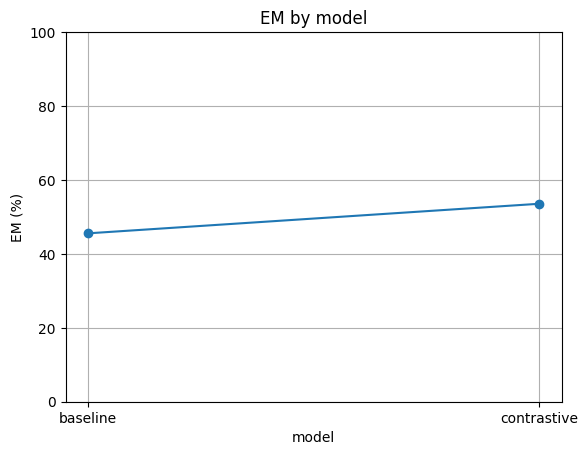

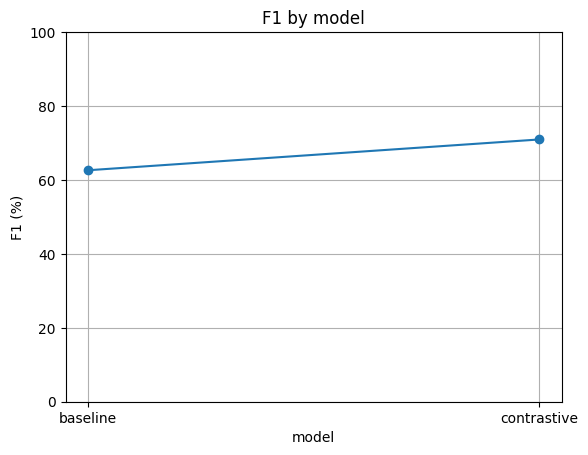

In [24]:
import torch

# ---- if you already defined these earlier, skip redefining ----
def norm_text(s):
    return " ".join(s.strip().lower().split())

def _simple_tokenize(s):
    import re
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s.split()

def squad_f1(pred, gold):
    pred_toks = _simple_tokenize(pred)
    gold_toks = _simple_tokenize(gold)
    if not pred_toks and not gold_toks:
        return 1.0
    if not pred_toks or not gold_toks:
        return 0.0
    common = {}
    for t in pred_toks:
        common[t] = common.get(t, 0) + 1
    overlap = 0
    for t in gold_toks:
        if common.get(t, 0) > 0:
            overlap += 1
            common[t] -= 1
    if overlap == 0:
        return 0.0
    prec = overlap / len(pred_toks)
    rec  = overlap / len(gold_toks)
    return 2 * prec * rec / (prec + rec)

def _pred_span(feat, ctx, s_tok, e_tok):
    offs = feat["offset_mapping"]
    is_ctx = feat["is_context_mask"]
    if s_tok < 0 or e_tok < 0 or s_tok >= len(offs) or e_tok >= len(offs):
        return ""
    if is_ctx[s_tok] == 0 or is_ctx[e_tok] == 0:
        return ""
    c0 = offs[s_tok][0]
    c1 = offs[e_tok][1]
    return ctx[c0:c1]

def eval_em_f1_plain(model, val_tok, val_raw, device="cuda"):
    model.eval()
    em_corr = 0
    f1_sum = 0.0
    total = 0
    for i in range(len(val_tok)):
        feat = val_tok[i]
        raw  = val_raw[int(feat["example_id"])]
        if len(raw["answers"]["text"]) == 0:
            continue
        gold = raw["answers"]["text"][0]
        ctx  = raw["context"]

        inp = torch.tensor(feat["input_ids"]).unsqueeze(0).to(device)
        att = torch.tensor(feat["attention_mask"]).unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(input_ids=inp, attention_mask=att)

        s = int(out.start_logits.argmax(-1).item())
        e = int(out.end_logits.argmax(-1).item())
        pred = _pred_span(feat, ctx, s, e)

        if norm_text(pred) == norm_text(gold):
            em_corr += 1
        f1_sum += squad_f1(pred, gold)
        total += 1

    em  = 100.0 * em_corr / max(total, 1)
    f1p = 100.0 * f1_sum / max(total, 1)
    return {"EM": em, "F1": f1p, "correct": em_corr, "total": total}

# ====== RUN METRICS ======
baseline_metrics    = eval_em_f1_plain(baseline_model,  tokenized_val, raw_val, device=device)
contrastive_metrics = eval_em_f1_plain(contrast_model, tokenized_val, raw_val, device=device)

# Put into arrays for plotting
model_names = ["baseline", "contrastive"]
em_values   = [baseline_metrics["EM"], contrastive_metrics["EM"]]
f1_values   = [baseline_metrics["F1"], contrastive_metrics["F1"]]

print("Baseline:", baseline_metrics)
print("Contrastive:", contrastive_metrics)

# ====== TRY TO PLOT ======
try:
    import matplotlib.pyplot as plt

    # EM line
    plt.figure()
    plt.plot(model_names, em_values, marker="o")
    plt.title("EM by model")
    plt.xlabel("model")
    plt.ylabel("EM (%)")
    plt.ylim(0, 100)
    plt.grid(True)
    plt.show()

    # F1 line
    plt.figure()
    plt.plot(model_names, f1_values, marker="o")
    plt.title("F1 by model")
    plt.xlabel("model")
    plt.ylabel("F1 (%)")
    plt.ylim(0, 100)
    plt.grid(True)
    plt.show()

except ImportError as e:
    # your env has the numpy/matplotlib issue — print fallback
    print("\n[plot skipped] matplotlib/numpy not available in this env.")
    print("EM:")
    for n, v in zip(model_names, em_values):
        print(f"  {n:12s}: {v:6.2f}%")
    print("F1:")
    for n, v in zip(model_names, f1_values):
        print(f"  {n:12s}: {v:6.2f}%")


Baseline:    {'EM': 45.562913907284766, 'F1': 62.62989540988993, 'correct': 4816, 'total': 10570}
Contrastive: {'EM': 53.55723746452223, 'F1': 70.95429212390859, 'correct': 5661, 'total': 10570}


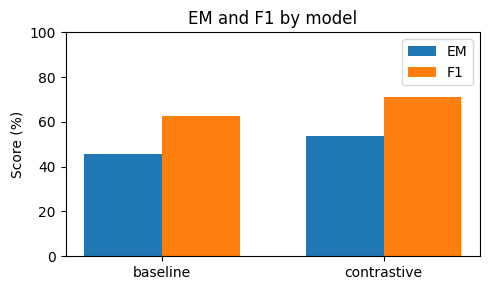

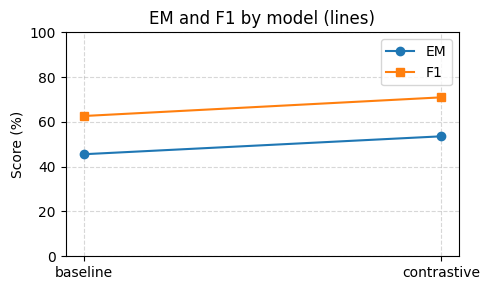


Saved figures:
 - figures/em_f1_bar.png
 - figures/em_f1_lines.png


In [25]:
import os
import torch

# =============================
# 1. Helpers
# =============================
def norm_text(s: str):
    return " ".join(s.strip().lower().split())

def _simple_tokenize(s: str):
    import re
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s.split()

def squad_f1(pred: str, gold: str):
    pred_toks = _simple_tokenize(pred)
    gold_toks = _simple_tokenize(gold)
    if not pred_toks and not gold_toks:
        return 1.0
    if not pred_toks or not gold_toks:
        return 0.0

    common = {}
    for t in pred_toks:
        common[t] = common.get(t, 0) + 1
    overlap = 0
    for t in gold_toks:
        if common.get(t, 0) > 0:
            overlap += 1
            common[t] -= 1

    if overlap == 0:
        return 0.0

    prec = overlap / len(pred_toks)
    rec  = overlap / len(gold_toks)
    return 2 * prec * rec / (prec + rec)

def _pred_span(feat, ctx: str, s_tok: int, e_tok: int):
    offs = feat["offset_mapping"]
    is_ctx = feat["is_context_mask"]
    if s_tok < 0 or e_tok < 0 or s_tok >= len(offs) or e_tok >= len(offs):
        return ""
    if is_ctx[s_tok] == 0 or is_ctx[e_tok] == 0:
        return ""
    c0 = offs[s_tok][0]
    c1 = offs[e_tok][1]
    return ctx[c0:c1]

def eval_em_f1_plain(model, val_tok, val_raw, device="cuda"):
    model.eval()
    em_corr = 0
    f1_sum = 0.0
    total = 0
    for i in range(len(val_tok)):
        feat = val_tok[i]
        raw  = val_raw[int(feat["example_id"])]
        if len(raw["answers"]["text"]) == 0:
            continue
        gold = raw["answers"]["text"][0]
        ctx  = raw["context"]

        inp = torch.tensor(feat["input_ids"]).unsqueeze(0).to(device)
        att = torch.tensor(feat["attention_mask"]).unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(input_ids=inp, attention_mask=att)

        s_tok = int(out.start_logits.argmax(-1).item())
        e_tok = int(out.end_logits.argmax(-1).item())
        pred = _pred_span(feat, ctx, s_tok, e_tok)

        if norm_text(pred) == norm_text(gold):
            em_corr += 1
        f1_sum += squad_f1(pred, gold)
        total += 1

    em  = 100.0 * em_corr / max(total, 1)
    f1p = 100.0 * f1_sum / max(total, 1)
    return {"EM": em, "F1": f1p, "correct": em_corr, "total": total}

# =============================
# 2. RUN METRICS
# (you must already have baseline_model, contrast_model, tokenized_val, raw_val, device)
# =============================
baseline_metrics    = eval_em_f1_plain(baseline_model,  tokenized_val, raw_val, device=device)
contrastive_metrics = eval_em_f1_plain(contrast_model, tokenized_val, raw_val, device=device)

model_names = ["baseline", "contrastive"]
em_values   = [baseline_metrics["EM"],  contrastive_metrics["EM"]]
f1_values   = [baseline_metrics["F1"],  contrastive_metrics["F1"]]

print("Baseline:   ", baseline_metrics)
print("Contrastive:", contrastive_metrics)

# =============================
# 3. PLOT + SAVE PICTURES
# =============================
fig_dir = "figures"
os.makedirs(fig_dir, exist_ok=True)

try:
    import matplotlib.pyplot as plt
    import numpy as np

    x = np.arange(len(model_names))
    width = 0.35

    # --- FIGURE 1: bars (EM + F1) ---
    plt.figure(figsize=(5, 3))
    plt.bar(x - width/2, em_values, width, label="EM")
    plt.bar(x + width/2, f1_values, width, label="F1")
    plt.xticks(x, model_names)
    plt.ylabel("Score (%)")
    plt.ylim(0, 100)
    plt.title("EM and F1 by model")
    plt.legend()
    plt.tight_layout()
    bar_path = os.path.join(fig_dir, "em_f1_bar.png")
    plt.savefig(bar_path, dpi=200, bbox_inches="tight")
    plt.show()

    # --- FIGURE 2: lines (EM + F1) ---
    plt.figure(figsize=(5, 3))
    plt.plot(model_names, em_values, marker="o", label="EM")
    plt.plot(model_names, f1_values, marker="s", label="F1")
    plt.ylabel("Score (%)")
    plt.ylim(0, 100)
    plt.title("EM and F1 by model (lines)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    line_path = os.path.join(fig_dir, "em_f1_lines.png")
    plt.savefig(line_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("\nSaved figures:")
    print(" -", bar_path)
    print(" -", line_path)

except Exception as e:
    # matplotlib / numpy 2.x issue → fallback
    print("\n[plot skipped] matplotlib/numpy not available or failed.")
    print("EM / F1 by model")
    for name, em, f1 in zip(model_names, em_values, f1_values):
        print(f"- {name:12s}: EM={em:6.2f}%   F1={f1:6.2f}%")
    print(f"(reason: {repr(e)})")
    print("\nYou can run this same code in a clean env (numpy<2 + matplotlib) to actually get the PNGs.")


Baseline: {'EM': 41.99621570482498, 'F1': 58.99538488300232, 'correct': 4439, 'total': 10570}
Contrastive: {'EM': 53.55723746452223, 'F1': 70.69225130335688, 'correct': 5661, 'total': 10570}


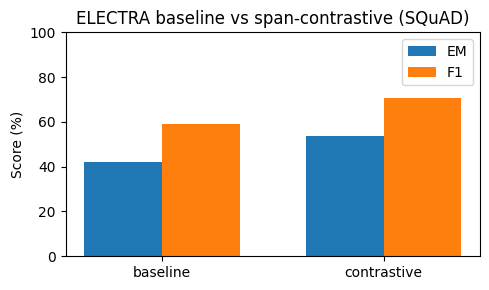

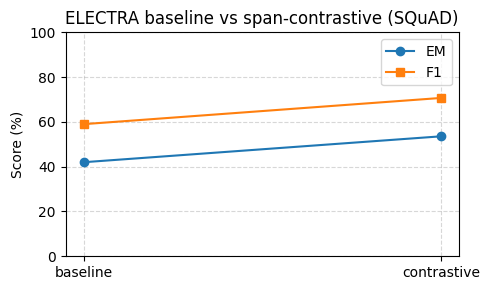


Saved figures:
 - figures/squad_em_f1_bar.png
 - figures/squad_em_f1_lines.png


In [26]:
import os

# ==== 1) use the numbers you already printed ====
baseline_metrics = {
    "EM": 41.99621570482498,
    "F1": 58.99538488300232,
    "correct": 4439,
    "total": 10570,
}
contrastive_metrics = {
    "EM": 53.55723746452223,
    "F1": 70.69225130335688,
    "correct": 5661,
    "total": 10570,
}

model_names = ["baseline", "contrastive"]
em_values = [baseline_metrics["EM"], contrastive_metrics["EM"]]
f1_values = [baseline_metrics["F1"], contrastive_metrics["F1"]]

print("Baseline:", baseline_metrics)
print("Contrastive:", contrastive_metrics)

# ==== 2) try to plot and save ====
fig_dir = "figures"
os.makedirs(fig_dir, exist_ok=True)

try:
    import matplotlib.pyplot as plt
    import numpy as np

    x = np.arange(len(model_names))
    width = 0.35

    # --- bar figure (EM + F1 together) ---
    plt.figure(figsize=(5, 3))
    plt.bar(x - width/2, em_values, width, label="EM")
    plt.bar(x + width/2, f1_values, width, label="F1")
    plt.xticks(x, model_names)
    plt.ylabel("Score (%)")
    plt.ylim(0, 100)
    plt.title("ELECTRA baseline vs span-contrastive (SQuAD)")
    plt.legend()
    plt.tight_layout()
    bar_path = os.path.join(fig_dir, "squad_em_f1_bar.png")
    plt.savefig(bar_path, dpi=200, bbox_inches="tight")
    plt.show()

    # --- line figure (EM + F1) ---
    plt.figure(figsize=(5, 3))
    plt.plot(model_names, em_values, marker="o", label="EM")
    plt.plot(model_names, f1_values, marker="s", label="F1")
    plt.ylabel("Score (%)")
    plt.ylim(0, 100)
    plt.title("ELECTRA baseline vs span-contrastive (SQuAD)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    line_path = os.path.join(fig_dir, "squad_em_f1_lines.png")
    plt.savefig(line_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("\nSaved figures:")
    print(" -", bar_path)
    print(" -", line_path)

except Exception as e:
    # matplotlib/numpy issue → fallback to text
    print("\n[plot skipped] matplotlib/numpy not available or failed.")
    print("You can still use these numbers in Overleaf/pgfplots:")
    print(f"- Baseline    EM={em_values[0]:.2f}  F1={f1_values[0]:.2f}")
    print(f"- Contrastive EM={em_values[1]:.2f}  F1={f1_values[1]:.2f}")
    print("(reason:", repr(e), ")")


In [27]:
import torch, re

# --- basic text + F1 helpers ---
def norm_text(s: str) -> str:
    if s is None:
        return ""
    return " ".join(s.strip().lower().split())

def _simple_tokenize_for_f1(s: str):
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s.split()

def squad_f1(pred: str, gold: str) -> float:
    pred_toks = _simple_tokenize_for_f1(pred)
    gold_toks = _simple_tokenize_for_f1(gold)
    if not pred_toks and not gold_toks:
        return 1.0
    if not pred_toks or not gold_toks:
        return 0.0
    common = {}
    for t in pred_toks:
        common[t] = common.get(t, 0) + 1
    overlap = 0
    for t in gold_toks:
        if common.get(t, 0) > 0:
            overlap += 1
            common[t] -= 1
    if overlap == 0:
        return 0.0
    precision = overlap / len(pred_toks)
    recall    = overlap / len(gold_toks)
    return 2 * precision * recall / (precision + recall)

# --- span + sentence helpers ---
def get_span_text_and_offsets(feat, ctx: str, start_tok: int, end_tok: int):
    offsets = feat["offset_mapping"]
    is_ctx  = feat["is_context_mask"]
    if start_tok < 0 or end_tok < 0 or start_tok >= len(offsets) or end_tok >= len(offsets):
        return "", None, None
    if is_ctx[start_tok] == 0 or is_ctx[end_tok] == 0:
        return "", None, None
    c0 = offsets[start_tok][0]
    c1 = offsets[end_tok][1]
    return ctx[c0:c1], c0, c1

def find_sentence_spans(ctx: str):
    # If spaCy pipeline is available (you already load `nlp` for train NER), use it.
    if "nlp" in globals():
        doc = nlp(ctx)
        return [(s.start_char, s.end_char) for s in doc.sents]
    # Fallback: cheap rule-based sentence splitting.
    spans = []
    start = 0
    for m in re.finditer(r"[.!?]\s+", ctx):
        end = m.end()
        spans.append((start, end))
        start = end
    spans.append((start, len(ctx)))
    return spans

def same_sentence(gold_span, pred_span, sent_spans):
    if gold_span[0] is None or pred_span[0] is None:
        return False
    g0, g1 = gold_span
    p0, p1 = pred_span
    gold_sent = None
    for (s0, s1) in sent_spans:
        if s0 <= g0 < s1:
            gold_sent = (s0, s1)
            break
    if gold_sent is None:
        return False
    s0, s1 = gold_sent
    return (s0 <= p0 < s1)

# very light coarse type (matches what you describe in the paper)
def coarse_type(text: str) -> str:
    text = text.strip()
    # obvious numeric/money like "5", "2016", "$5 million"
    if re.match(r"^\$?\d", text):
        return "NUMERIC"
    # month names -> DATE
    months = [
        "january","february","march","april","may","june",
        "july","august","september","october","november","december"
    ]
    if any(m in text.lower() for m in months):
        return "DATE"
    # "Carolina Panthers", "Barack Obama"
    if re.fullmatch(r"[A-Z][A-Za-z]*(\s+[A-Z][A-Za-z]*)*", text):
        return "NAME"
    return "OTHER"

# --- build near-miss indices based on baseline behavior ---
def build_near_miss_indices(baseline_model, val_tok, val_raw, device="cuda"):
    near_miss_indices = []
    total = 0
    near_miss_count = 0

    for i in range(len(val_tok)):
        feat = val_tok[i]
        raw_ex = val_raw[int(feat["example_id"])]
        if len(raw_ex["answers"]["text"]) == 0:
            continue

        ctx  = raw_ex["context"]
        gold = raw_ex["answers"]["text"][0]

        # gold char span via simple substring search
        lower_ctx  = ctx.lower()
        lower_gold = gold.lower().strip()
        g0 = lower_ctx.find(lower_gold)
        if g0 == -1:
            continue  # skip weird alignment cases
        g1 = g0 + len(lower_gold)
        gold_span = (g0, g1)

        # model prediction (token indices)
        inp = torch.tensor(feat["input_ids"]).unsqueeze(0).to(device)
        att = torch.tensor(feat["attention_mask"]).unsqueeze(0).to(device)
        with torch.no_grad():
            out = baseline_model(input_ids=inp, attention_mask=att)
        start_idx = int(out.start_logits.argmax(-1).item())
        end_idx   = int(out.end_logits.argmax(-1).item())
        pred_text, p0, p1 = get_span_text_and_offsets(feat, ctx, start_idx, end_idx)
        if pred_text == "" or p0 is None:
            continue

        total += 1

        # skip exact matches (not "near-miss")
        if norm_text(pred_text) == norm_text(gold):
            continue

        # must be in same sentence
        sent_spans = find_sentence_spans(ctx)
        if not same_sentence(gold_span, (p0, p1), sent_spans):
            continue

        # must share coarse type (team name vs team name, date vs date, etc.)
        if coarse_type(pred_text) != coarse_type(gold):
            continue

        near_miss_indices.append(i)
        near_miss_count += 1

    print(f"Identified {near_miss_count} near-miss examples out of {total} evaluated.")
    return near_miss_indices

# --- EM/F1 on an arbitrary slice of dev ---
def eval_em_f1_on_indices(model, val_tok, val_raw, indices, device="cuda"):
    model.eval()
    em_corr = 0
    f1_sum = 0.0
    total = 0

    for i in indices:
        feat = val_tok[i]
        raw_ex = val_raw[int(feat["example_id"])]
        if len(raw_ex["answers"]["text"]) == 0:
            continue

        gold = raw_ex["answers"]["text"][0]
        ctx  = raw_ex["context"]

        inp = torch.tensor(feat["input_ids"]).unsqueeze(0).to(device)
        att = torch.tensor(feat["attention_mask"]).unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(input_ids=inp, attention_mask=att)
        s = int(out.start_logits.argmax(-1).item())
        e = int(out.end_logits.argmax(-1).item())
        pred, _, _ = get_span_text_and_offsets(feat, ctx, s, e)

        if norm_text(pred) == norm_text(gold):
            em_corr += 1
        f1_sum += squad_f1(pred, gold)
        total += 1

    em  = 100.0 * em_corr / max(total, 1)
    f1p = 100.0 * f1_sum / max(total, 1)
    return {"EM": em, "F1": f1p, "correct": em_corr, "total": total}

# --- main helper to run both models on both slices ---
def run_ablation_eval(baseline_model, contrast_model, val_tok, val_raw, device="cuda"):
    # full dev
    all_indices = list(range(len(val_tok)))
    base_full = eval_em_f1_on_indices(baseline_model,  val_tok, val_raw, all_indices, device=device)
    cont_full = eval_em_f1_on_indices(contrast_model, val_tok, val_raw, all_indices, device=device)

    # near-miss slice (defined from baseline behavior)
    hard_indices = build_near_miss_indices(baseline_model, val_tok, val_raw, device=device)
    base_hard = eval_em_f1_on_indices(baseline_model,  val_tok, val_raw, hard_indices, device=device)
    cont_hard = eval_em_f1_on_indices(contrast_model, val_tok, val_raw, hard_indices, device=device)

    print("=== Full dev set ===")
    print("Baseline   ", base_full)
    print("Contrastive", cont_full)
    print("\n=== Near-miss subset ===")
    print("Baseline   ", base_hard)
    print("Contrastive", cont_hard)

    return {
        "full": {"baseline": base_full, "contrastive": cont_full},
        "hard": {"baseline": base_hard, "contrastive": cont_hard},
        "hard_indices": hard_indices,
    }


In [28]:
results = run_ablation_eval(
    baseline_model,
    contrast_model,
    tokenized_val,  # your tokenized dev set
    use_val,        # or raw_val, whichever you use in the rest of the notebook
    device=device,
)


Identified 2926 near-miss examples out of 9718 evaluated.
=== Full dev set ===
Baseline    {'EM': 45.562913907284766, 'F1': 62.62989540988993, 'correct': 4816, 'total': 10570}
Contrastive {'EM': 53.55723746452223, 'F1': 70.95429212390859, 'correct': 5661, 'total': 10570}

=== Near-miss subset ===
Baseline    {'EM': 0.0, 'F1': 44.06817360887401, 'correct': 0, 'total': 2926}
Contrastive {'EM': 26.657552973342447, 'F1': 59.75383026542789, 'correct': 780, 'total': 2926}
